# Project 4

This project uses the Weekly data set. It contains 1,089 weekly stock-market percentage returns from 1990 through 2010.

Columns:
- Year: observation year
- Lag1 ... Lag5: percentage returns from the previous 1–5 weeks
- Volume: average daily volume in billions
- Today: percentage return for the current week
- Direction: Down or Up

## How checking works in this version

The notebook includes **limited public practice checks**. They are intentionally designed not to reveal the Project 4 answers or a readable reference solution.

- Complex fitted-model behavior is checked against an **opaque fingerprint** generated from unrelated synthetic data.
- Low-entropy answers such as accuracies and predictor lists are checked only for **type, range, structure, and invariants** so the notebook does not contain an answer that can simply be recovered.
- Passing the public checks does **not** guarantee full credit; Gradescope uses different hidden inputs for the official **20-point** coding score.

At the end of the notebook, use the conversion cell to turn the saved .ipynb into project4_submission.py. Gradescope extracts and tests the required function definitions from that converted file, so notebook plotting/setup cells do not affect grading.


## Getting Setup
Place Weekly.csv in the same folder as this notebook, then run the setup cells.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

print("Python:", sys.version.split()[0])
print("Pandas:", pd.__version__)

Python: 3.11.14
Pandas: 3.0.2


In [2]:
# -----------------------------------------------------------------------------
# Public practice checks — hardened version
# -----------------------------------------------------------------------------
# These checks are intentionally limited. They help catch interface/behavior
# mistakes without embedding the Project 4 answers or a readable reference
# implementation. Gradescope uses separate hidden tests for the official score.
#
# For model-fitting functions, correct behavior is compared with an opaque
# fingerprint. The expected predictions/coefficients are not stored in readable
# form. For low-entropy answers (such as accuracies or short lists), the local
# checks validate types, ranges, and invariants rather than revealing a target.

import hashlib
import json as _json

_PUBLIC_RESULTS = {}

def _public_result(name, passed, message=""):
    _PUBLIC_RESULTS[name] = bool(passed)
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {name}" + (f": {message}" if (message and not passed) else ""))
    return bool(passed)

def show_public_check_summary():
    if not _PUBLIC_RESULTS:
        print("No public checks have been run yet.")
        return
    passed = sum(_PUBLIC_RESULTS.values())
    print(f"Public checks passed: {passed}/{len(_PUBLIC_RESULTS)}")
    print("These practice checks are not the official Project 4 score.")
    print("A PASS confirms only the public behaviors checked here; Gradescope tests more cases.")

def _fingerprint(payload):
    text = _json.dumps(payload, sort_keys=True, separators=(",", ":"), allow_nan=False)
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def _rounded_floats(values, digits=6):
    return [round(float(x), digits) for x in np.asarray(values, dtype=float).reshape(-1)]

def check_load_weekly(func):
    import tempfile
    sample = pd.DataFrame({"A": [3, 1], "B": ["x", "y"]})
    with tempfile.NamedTemporaryFile(suffix=".csv", mode="w", delete=False) as f:
        sample.to_csv(f.name, index=False)
        path = f.name
    try:
        actual = func(path)
        ok = isinstance(actual, pd.DataFrame) and actual.equals(sample)
        return _public_result(
            "load_weekly", ok,
            "Return the contents of the supplied CSV as a pandas DataFrame."
        )
    except Exception as exc:
        return _public_result("load_weekly", False, f"{type(exc).__name__}: {exc}")
    finally:
        try:
            Path(path).unlink()
        except Exception:
            pass

def check_encode_direction(func):
    sample = pd.DataFrame(
        {"Direction": ["Up", "Down", "Up", "Down"], "Keep": [10, 20, 30, 40]},
        index=["r1", "r2", "r3", "r4"],
    )
    try:
        actual = func(sample.copy())
        structural = (
            isinstance(actual, pd.DataFrame)
            and actual.index.equals(sample.index)
            and actual.shape == sample.shape
            and "Direction" in actual.columns
            and actual["Keep"].equals(sample["Keep"])
        )
        if not structural:
            return _public_result(
                "encode_direction", False,
                "Return a same-shaped DataFrame and preserve non-Direction data."
            )
        values = pd.Series(actual["Direction"]).dropna()
        binary = len(values) == len(sample) and set(values.tolist()).issubset({0, 1})
        both_classes = set(values.tolist()) == {0, 1}
        return _public_result(
            "encode_direction", binary and both_classes,
            "Direction should become a complete binary numeric column."
        )
    except Exception as exc:
        return _public_result("encode_direction", False, f"{type(exc).__name__}: {exc}")

def _public_model_frame():
    # The feature values are synthetic and unrelated to Weekly.csv.  Labels are
    # fixed practice inputs; no expected model output is exposed below.
    rng = np.random.default_rng(4104)
    n = 48
    out = pd.DataFrame({
        "Year": np.array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2003] * 6)[:n],
        "Lag1": rng.normal(0, 1, n),
        "Lag2": rng.normal(0, 1, n),
        "Lag3": rng.normal(0, 1, n),
        "Lag4": rng.normal(0, 1, n),
        "Lag5": rng.normal(0, 1, n),
        "Volume": rng.uniform(0.5, 2.0, n),
        "Today": rng.normal(0.3, 0.9, n),
    })
    out["Direction"] = [
        0,0,1,1,1,0,1,1,0,1,1,1,1,0,0,0,1,1,0,0,1,0,1,0,
        0,0,0,1,1,0,0,1,1,0,0,0,0,1,1,1,0,0,1,0,0,1,1,1,
    ]
    out["Response"] = [
        0,1,0,0,1,0,0,1,0,1,1,1,0,1,1,0,0,0,0,1,1,0,1,0,
        1,1,1,1,0,0,1,0,1,1,0,1,0,0,1,1,0,1,0,0,1,1,0,1,
    ]
    return out

def check_fit_full_direction_logit(func):
    sample = _public_model_frame()
    try:
        fit = func(sample.copy())
        if not hasattr(fit, "predict"):
            return _public_result(
                "fit_full_direction_logit", False,
                "Return a fitted model object with a predict method."
            )
        payload = {
            "nobs": int(round(float(getattr(fit, "nobs", -1)))),
            "preds": _rounded_floats(fit.predict(sample.iloc[:8]), 6),
        }
        # Opaque fingerprint of correct behavior on the synthetic public case.
        expected_fp = "47af9a62390201fd28ed397b2a119a4a3886e82a0f920e534299a3100e89bab4"
        return _public_result(
            "fit_full_direction_logit",
            _fingerprint(payload) == expected_fp,
            "The fitted model does not match the public behavioral check."
        )
    except Exception as exc:
        return _public_result("fit_full_direction_logit", False, f"{type(exc).__name__}: {exc}")

def check_get_significant_predictors(func):
    class PracticeFit:
        pvalues = pd.Series({
            "Intercept": 0.013, "Lag1": 0.61, "Lag2": 0.027,
            "Lag3": 0.18, "Lag4": 0.071, "Lag5": 0.44,
        })
    try:
        low = func(PracticeFit(), alpha=0.01)
        high = func(PracticeFit(), alpha=0.20)
        candidates = {"Lag1", "Lag2", "Lag3", "Lag4", "Lag5"}
        def valid(x):
            return (
                isinstance(x, (list, tuple))
                and all(isinstance(v, str) for v in x)
                and "Intercept" not in x
                and set(x).issubset(candidates)
                and len(set(x)) == len(x)
            )
        monotone = valid(low) and valid(high) and set(low).issubset(set(high))
        return _public_result(
            "get_significant_predictors", monotone,
            "Return predictor names only; exclude the intercept and respect alpha consistently."
        )
    except Exception as exc:
        return _public_result("get_significant_predictors", False, f"{type(exc).__name__}: {exc}")

def _check_accuracy_behavior(func, name):
    sample = _public_model_frame()
    try:
        a = float(func(sample.copy()))
        b = float(func(sample.sample(frac=1, random_state=17).copy()))
        ok = np.isfinite(a) and np.isfinite(b) and 0.0 <= a <= 1.0 and 0.0 <= b <= 1.0
        invariant = ok and np.isclose(a, b, rtol=1e-10, atol=1e-10)
        return _public_result(
            name, invariant,
            "Return a finite accuracy in [0, 1]; row order should not change it."
        )
    except Exception as exc:
        return _public_result(name, False, f"{type(exc).__name__}: {exc}")

def check_full_direction_accuracy(func):
    return _check_accuracy_behavior(func, "full_direction_accuracy")

def check_split_direction_train_test(func):
    sample = pd.DataFrame(
        {"Year": [2007, 2008, 1999, 2010, 2006], "v": [1, 2, 3, 4, 5]},
        index=["a", "b", "c", "d", "e"],
    )
    try:
        train, test = func(sample.copy())
        if not isinstance(train, pd.DataFrame) or not isinstance(test, pd.DataFrame):
            return _public_result(
                "split_direction_train_test", False,
                "Return two pandas DataFrames: training first, held-out second."
            )
        payload = {
            "train": [str(x) for x in train.index.tolist()],
            "test": [str(x) for x in test.index.tolist()],
        }
        expected_fp = "0d9368367454f58f62f6ea82c4888feb43b98ce61dd8641be0a7b8768b0e65c3"
        return _public_result(
            "split_direction_train_test",
            _fingerprint(payload) == expected_fp,
            "The public split does not match the assignment's training/held-out rule."
        )
    except Exception as exc:
        return _public_result("split_direction_train_test", False, f"{type(exc).__name__}: {exc}")

def check_direction_holdout_accuracy(func):
    return _check_accuracy_behavior(func, "direction_holdout_accuracy")

def check_add_response(func):
    sample = pd.DataFrame(
        {"Today": [0.51, 0.50, -1.0, 2.2, 0.49], "Keep": [1, 2, 3, 4, 5]},
        index=["a", "b", "c", "d", "e"],
    )
    try:
        actual = func(sample.copy())
        structural = (
            isinstance(actual, pd.DataFrame)
            and actual.index.equals(sample.index)
            and len(actual) == len(sample)
            and "Response" in actual.columns
            and actual["Today"].equals(sample["Today"])
            and actual["Keep"].equals(sample["Keep"])
        )
        if not structural:
            return _public_result(
                "add_response", False,
                "Preserve the input rows/columns and add a Response column."
            )
        values = pd.Series(actual["Response"]).dropna()
        binary = len(values) == len(sample) and set(values.tolist()).issubset({0, 1})
        both_classes = set(values.tolist()) == {0, 1}
        return _public_result(
            "add_response", binary and both_classes,
            "Response should be a complete binary column while preserving the input data."
        )
    except Exception as exc:
        return _public_result("add_response", False, f"{type(exc).__name__}: {exc}")

def check_fit_response_logit(func):
    sample = _public_model_frame()
    try:
        fit = func(sample.copy())
        if not hasattr(fit, "predict"):
            return _public_result(
                "fit_response_logit", False,
                "Return a fitted model object with a predict method."
            )
        payload = {
            "nobs": int(round(float(getattr(fit, "nobs", -1)))),
            "preds": _rounded_floats(fit.predict(sample.iloc[:8]), 6),
        }
        expected_fp = "fa7c29cedc466400b5527dfc373256bb0bf2a1125e18b012529d7331960a741b"
        return _public_result(
            "fit_response_logit",
            _fingerprint(payload) == expected_fp,
            "The fitted model does not match the public behavioral check."
        )
    except Exception as exc:
        return _public_result("fit_response_logit", False, f"{type(exc).__name__}: {exc}")

def check_response_holdout_accuracy(func):
    return _check_accuracy_behavior(func, "response_holdout_accuracy")


## Part A
We are first interested in predicting the direction of the returns.

### A0. Load the data
Implement load_weekly(path) so that it loads a CSV and returns a pandas DataFrame.

In [3]:
def load_weekly(path="Weekly.csv"):
    return pd.read_csv(path)

weekly = load_weekly("Weekly.csv")
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [4]:
check_load_weekly(load_weekly)

[PASS] load_weekly


True

### A1. Encode Direction
Transform Direction into a numerical feature equal to 1 when Direction = Up and 0 otherwise. Implement encode_direction(df) and return the resulting DataFrame.

In [5]:
def encode_direction(df):
    df = df.copy()
    df["Direction"] = df["Direction"].map({"Up": 1, "Down": 0})
    return df

weekly = encode_direction(weekly)
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1


In [6]:
check_encode_direction(encode_direction)

[PASS] encode_direction


True

Produce numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [7]:
# YOUR CODE HERE
# Suggested ideas: describe(), correlations, scatter-matrix, or other useful summaries.
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899,0.555556
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927,0.497132
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000,0.000000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000,0.000000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000,1.000000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000,1.000000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000,1.000000


In [8]:
weekly.corr(method="spearman").style.map(
    lambda x: "background-color: green" if abs(x) > 0.5 else ""    
)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000000,-0.015549,-0.017678,-0.014094,-0.015871,-0.015707,0.986357,-0.015502,-0.022269
Lag1,-0.015549,1.000000,-0.086558,0.051799,-0.018228,-0.011973,-0.015813,-0.086996,-0.061500
Lag2,-0.017678,-0.086558,1.000000,-0.087873,0.050964,-0.020346,-0.037088,0.052464,0.060918
Lag3,-0.014094,0.051799,-0.087873,1.000000,-0.087283,0.053078,-0.027425,-0.018168,-0.011498
Lag4,-0.015871,-0.018228,0.050964,-0.087283,1.000000,-0.087722,-0.025621,-0.011533,-0.017089
Lag5,-0.015707,-0.011973,-0.020346,0.053078,-0.087722,1.000000,-0.024148,-0.044541,-0.035629
Volume,0.986357,-0.015813,-0.037088,-0.027425,-0.025621,-0.024148,1.000000,-0.013910,-0.024578
Today,-0.015502,-0.086996,0.052464,-0.018168,-0.011533,-0.044541,-0.013910,1.000000,0.860664
Direction,-0.022269,-0.061500,0.060918,-0.011498,-0.017089,-0.035629,-0.024578,0.860664,1.000000


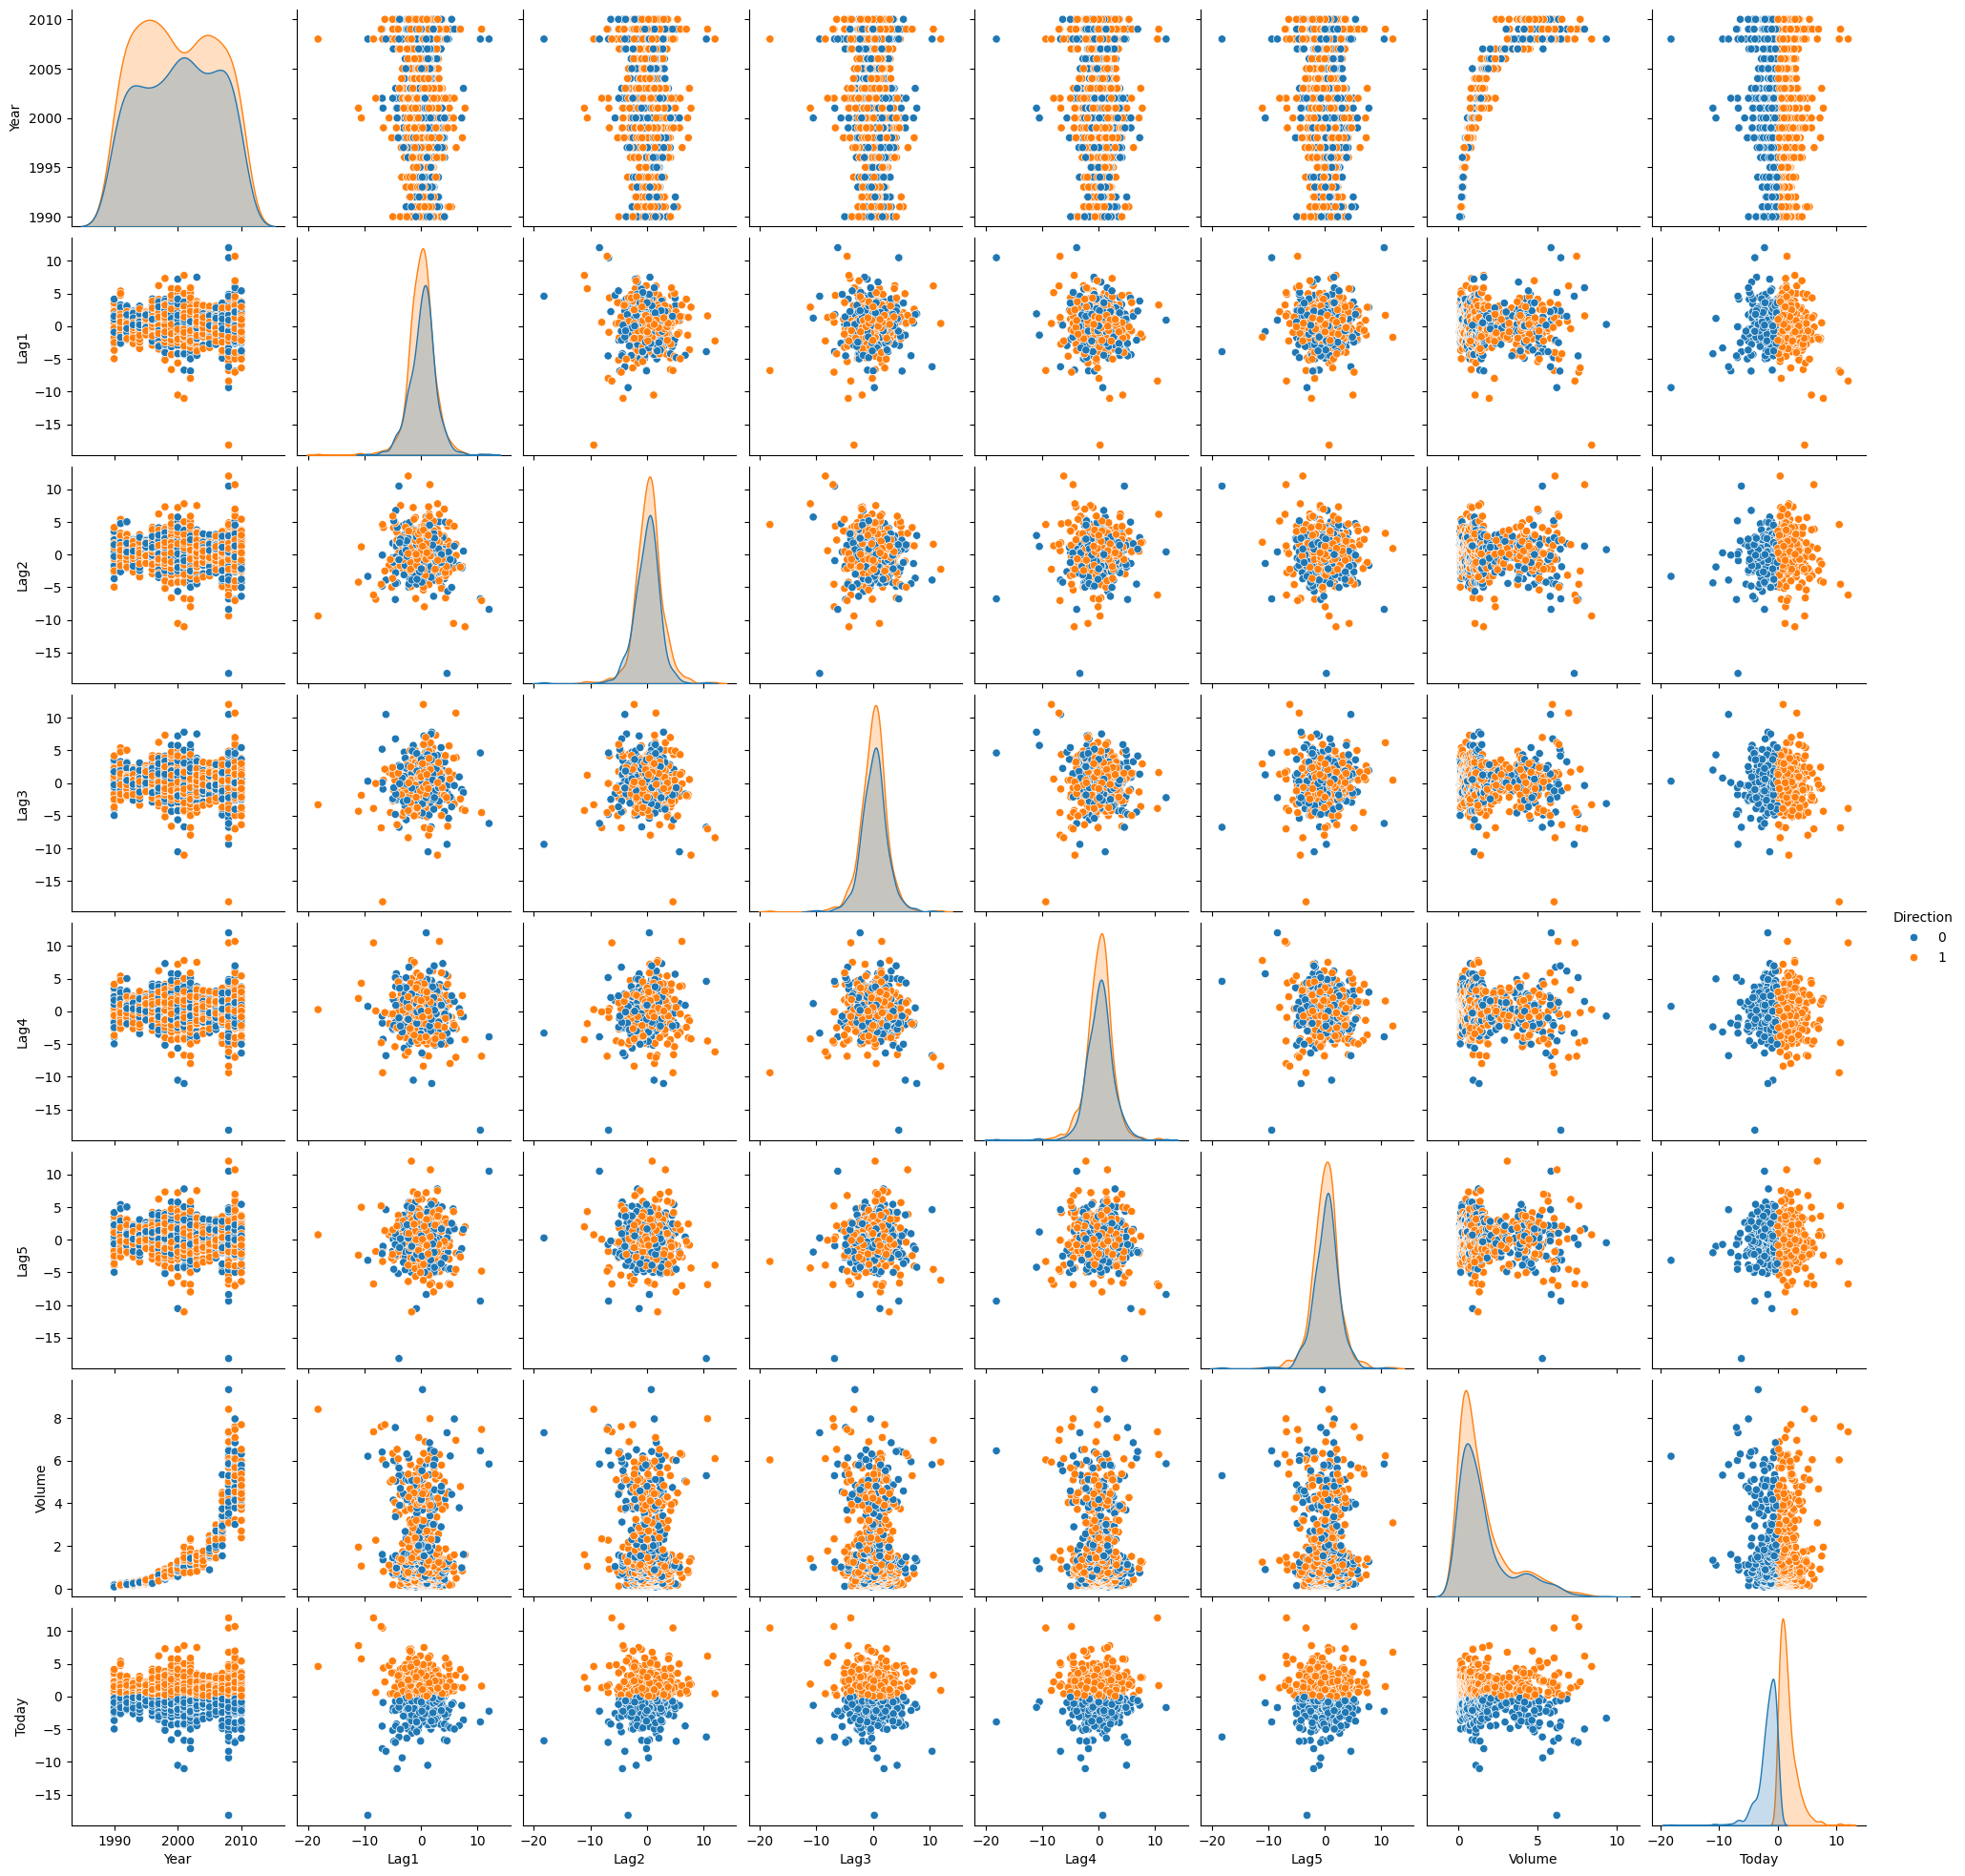

In [9]:
sns.pairplot(weekly, hue='Direction', diag_kind='kde')
plt.show()

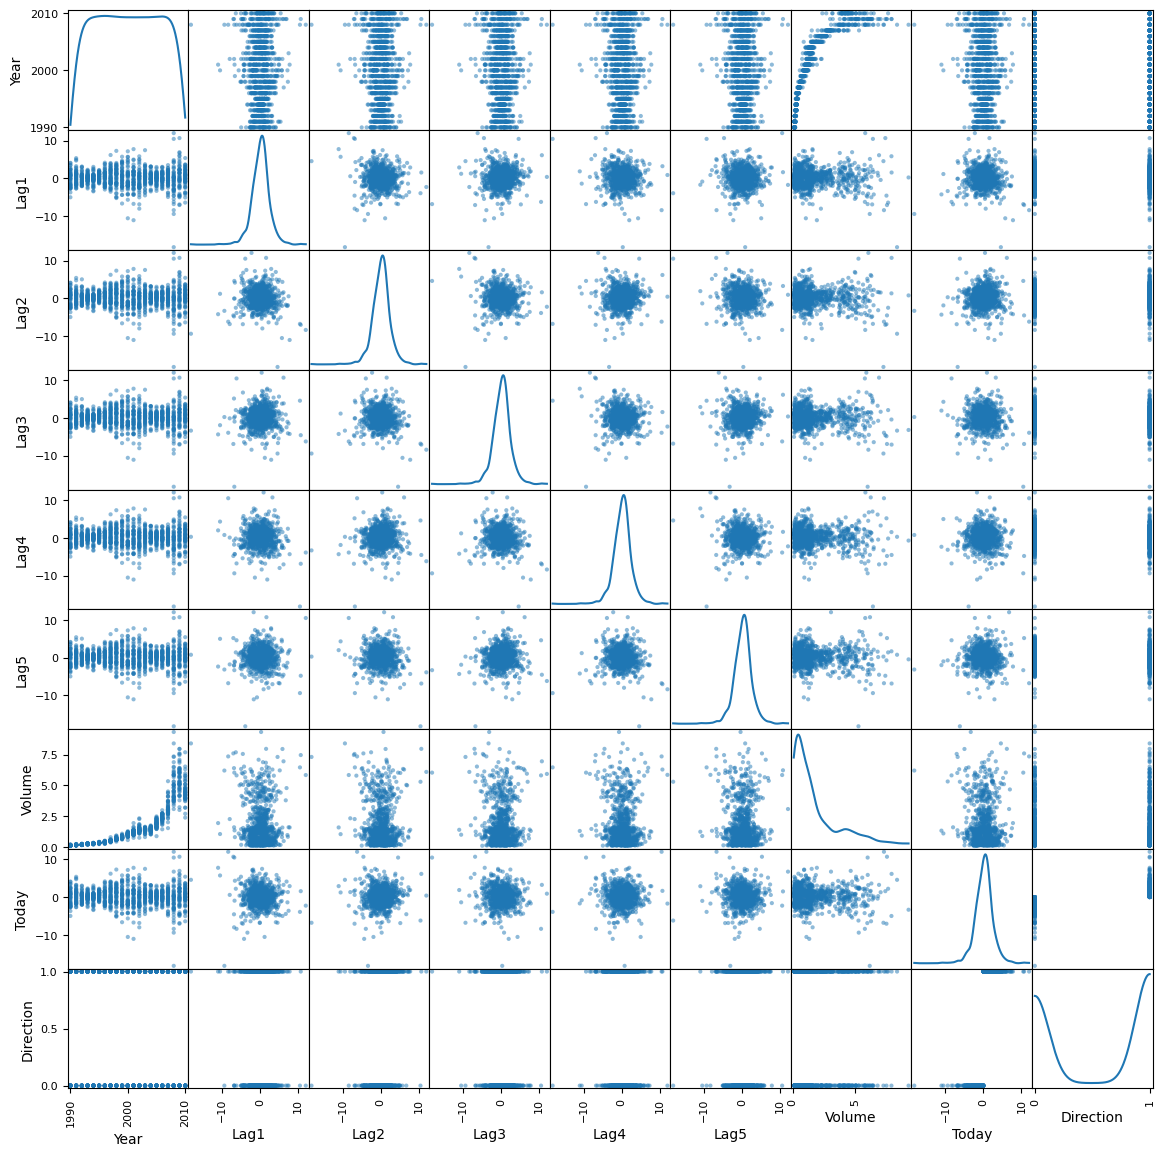

In [10]:
pd.plotting.scatter_matrix(
    weekly,
    figsize=(14, 14),
    diagonal="kde",
    alpha=0.5
)
plt.show()

Include a brief description of the relationships and correlations you find.

In [11]:
relationships = """
1. As the year increases, the volume of trades tends to increase as well. This could be due to increased market participation and technological advancements in trading platforms.
2. Today and Direction have a very strong correlation (0.861), but Today should not be used to predict Direction because Direction is derived from Today.
3. All lag variables have correlations close to zero with Direction but they have a weak linear relationship with direction.
  """

### A2. Full logistic regression
Using the full data set, fit a logistic regression with Direction as the response and the five lag variables as predictors.

Implement fit_full_direction_logit(df) and return the **fitted statsmodels result**.

In [12]:
def fit_full_direction_logit(df):
    model = smf.logit(
        "Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5",
        data=df
    )
    return model.fit(disp=False)

fit1 = fit_full_direction_logit(weekly)
print(fit1.summary())

                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1083
Method:                           MLE   Df Model:                            5
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                0.006327
Time:                        21:08:12   Log-Likelihood:                -743.37
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                   0.09186
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2303      0.062      3.712      0.000       0.109       0.352
Lag1          -0.0401      0.026     -1.522      0.128      -0.092       0.012
Lag2           0.0602      0.027      2.249      0.0

In [13]:
check_fit_full_direction_logit(fit_full_direction_logit)

[PASS] fit_full_direction_logit


True

### A3. Statistical significance
Use the model summary to decide which predictors appear statistically significant.

Implement get_significant_predictors(fitted_model, alpha=0.05) so it returns a list containing the predictor names with p-values below alpha. Do **not** include the intercept.

In [14]:
def get_significant_predictors(fitted_model, alpha=0.05):
    pvalues = fitted_model.pvalues
    return [
        name for name, pvalue in pvalues.items()
        if name != "Intercept" and pvalue < alpha
    ]


var_significant = get_significant_predictors(fit1)
num_significant = len(var_significant)
print("Number significant:", num_significant)
print("Significant predictors:", var_significant)

Number significant: 1
Significant predictors: ['Lag2']


In [15]:
check_get_significant_predictors(get_significant_predictors)

[PASS] get_significant_predictors


True

### A4. Overall classification accuracy
Using a probability threshold of **0.5**, compute the fraction of observations correctly classified by the full model.

Implement full_direction_accuracy(df) and return one numeric value between 0 and 1.

In [16]:
def full_direction_accuracy(df):
    model = smf.logit(
        "Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5",
        data=df
    )
    fitted_model = model.fit(disp=False)
    predictions = (fitted_model.predict(df) >= 0.5).astype(int)
    return (predictions == df["Direction"]).mean()

fraction_correct_all = full_direction_accuracy(weekly)
print(f"Overall fraction of correct predictions is {fraction_correct_all}")

Overall fraction of correct predictions is 0.5629017447199265


In [17]:
check_full_direction_accuracy(full_direction_accuracy)

[PASS] full_direction_accuracy


True

### A5. Held-out evaluation
Use 1990–2007 as training data and 2008–2010 as held-out test data. First implement split_direction_train_test(df) and return (train, test) in that order.

In [18]:
def split_direction_train_test(df):
    train = df[df["Year"] < 2008]
    test = df[df["Year"] >= 2008]
    return train, test

train, test = split_direction_train_test(weekly)
print(train.shape, test.shape)

(933, 9) (156, 9)


In [19]:
check_split_direction_train_test(split_direction_train_test)

[PASS] split_direction_train_test


True

Fit a logistic regression on the training period using **Lag2 as the only predictor**, then compute the classification accuracy on the held-out data. Implement direction_holdout_accuracy(df).

In [20]:
def direction_holdout_accuracy(df):
    train, test = split_direction_train_test(df)
    model = smf.logit("Direction ~ Lag2", data=train)
    fitted_model = model.fit(disp=False)
    predictions = (fitted_model.predict(test) >= 0.5).astype(int)
    return (predictions == test["Direction"]).mean()

fraction_correct_test = direction_holdout_accuracy(weekly)
print(f"Held-out fraction correct: {fraction_correct_test}")

Held-out fraction correct: 0.5512820512820513


In [21]:
check_direction_holdout_accuracy(direction_holdout_accuracy)

[PASS] direction_holdout_accuracy


True

## Part B
Now develop an investment response in which we buy when the current return is greater than 0.5% and sell otherwise.

### B1. Response variable
Create Response = 1 when Today > 0.5 and 0 otherwise. Implement add_response(df) and return the resulting DataFrame.

In [31]:
def add_response(df):
    df = df.copy()
    df["Response"] = (df["Today"] > 0.5).astype(int)
    return df

weekly = add_response(weekly)
weekly[["Today", "Response"]].head()

,Today,Response
0,-0.270,0
1,-2.576,0
2,3.514,1
3,0.712,1
4,1.178,1


In [32]:
check_add_response(add_response)

[PASS] add_response


True

### B2. Response logistic regression
Fit a logistic regression to predict Response using **1990–2008** as the training period and Volume, Lag1, Lag2, Lag3, Lag4, and Lag5 as predictors.

Implement fit_response_logit(df) and return the fitted statsmodels result.

In [33]:
def fit_response_logit(df):
    train = df[df["Year"] <= 2008]
    model = smf.logit(
        "Response ~ Volume + Lag1 + Lag2 + Lag3 + Lag4 + Lag5",
        data=train
    )
    return model.fit(disp=False)

fit3 = fit_response_logit(weekly)
print(fit3.summary())

                           Logit Regression Results                           
Dep. Variable:               Response   No. Observations:                  985
Model:                          Logit   Df Residuals:                      978
Method:                           MLE   Df Model:                            6
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                0.008988
Time:                        21:26:16   Log-Likelihood:                -671.06
converged:                       True   LL-Null:                       -677.14
Covariance Type:            nonrobust   LLR p-value:                   0.05825
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0780      0.094     -0.831      0.406      -0.262       0.106
Volume        -0.1039      0.055     -1.886      0.059      -0.212       0.004
Lag1          -0.0737      0.029     -2.500      0.0

In [34]:
check_fit_response_logit(fit_response_logit)

[PASS] fit_response_logit


True

### B3. Statistical significance
Use your get_significant_predictors function on the fitted Part B model and report the significant predictors.

In [35]:
var_significant_B = get_significant_predictors(fit3)
num_significant_B = len(var_significant_B)
print("Number significant:", num_significant_B)
print("Significant predictors:", var_significant_B)

Number significant: 1
Significant predictors: ['Lag1']


### B4. Held-out investment-response accuracy
Compute the classification accuracy on the held-out **2009–2010** observations using a threshold of 0.5. Implement response_holdout_accuracy(df).

In [44]:
def response_holdout_accuracy(df):
    train = df[df["Year"] <= 2008]
    test = df[df["Year"] >= 2009]

    model = smf.logit(
        "Response ~ Volume + Lag1 + Lag2 + Lag3 + Lag4 + Lag5",
        data=train
    )
    fitted_model = model.fit(disp=False)

    predictions = (fitted_model.predict(test) >= 0.5).astype(int)
    return (predictions == test["Response"]).mean()


fraction_correct = response_holdout_accuracy(weekly)
print(f"Held-out response accuracy: {fraction_correct}")

Held-out response accuracy: 0.5


In [45]:
check_response_holdout_accuracy(response_holdout_accuracy)

[PASS] response_holdout_accuracy


True

## Public-check summary
This is only a convenience summary. The public checks intentionally reveal less than the hidden grader, so passing every public check does not guarantee a 20/20 on Gradescope.


In [46]:
show_public_check_summary()

Public checks passed: 10/10
These practice checks are not the official Project 4 score.
A PASS confirms only the public behaviors checked here; Gradescope tests more cases.


## Convert the notebook to a .py file for Gradescope

1. **Save the notebook first.**
2. Run the cell below.
3. The function converts the complete .ipynb to project4_submission.py and verifies that the generated file is valid Python.
4. In Google Colab it will automatically trigger a download. In Jupyter/Codio it leaves the .py file in the working folder.

Gradescope extracts the required function definitions from the converted file, so it does not execute the notebook's top-level plotting or public-check cells.

In [47]:
def download_notebook_as_py(ipynb_path="project4_student_gradescope.ipynb",
                            output_name="project4_submission.py"):
    """Convert a saved Jupyter notebook to a Python file and download it in Colab."""
    from pathlib import Path
    import subprocess
    import sys

    ipynb_path = Path(ipynb_path)

    # Helpful fallback if the notebook was renamed but there is only one Project 4 notebook.
    if not ipynb_path.exists():
        candidates = sorted(Path.cwd().glob("*project4*.ipynb")) + sorted(Path.cwd().glob("*Project4*.ipynb"))
        # Deduplicate while preserving order.
        candidates = list(dict.fromkeys(candidates))
        if len(candidates) == 1:
            ipynb_path = candidates[0]
        else:
            raise FileNotFoundError(
                f"Could not find {ipynb_path}. Save the notebook and pass its exact filename to download_notebook_as_py(...)."
            )

    if ipynb_path.suffix.lower() != ".ipynb":
        raise ValueError("The input file must be a .ipynb notebook.")

    output_path = Path(output_name)
    if output_path.suffix.lower() != ".py":
        output_path = output_path.with_suffix(".py")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "jupyter",
            "nbconvert",
            "--to",
            "python",
            str(ipynb_path),
            "--output",
            output_path.stem,
            "--output-dir",
            str(output_path.parent.resolve()),
        ],
        check=True,
    )

    generated = output_path.resolve()
    source = generated.read_text(encoding="utf-8")
    compile(source, str(generated), "exec")
    print(f"Created and syntax-checked: {generated}")
    print("Upload this .py file to Gradescope.")

    try:
        from google.colab import files
        files.download(str(generated))
    except ImportError:
        print("Not running in Google Colab; the file remains in the current working directory.")

    return str(generated)

# Save the notebook before running this line. If you renamed the notebook,
# replace the first argument with its actual filename.
download_notebook_as_py("project4_student_gradescope.ipynb", "project4_submission.py")

[NbConvertApp] Converting notebook /Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_4/project4_student.ipynb to python


Created and syntax-checked: /Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_4/project4_submission.py
Upload this .py file to Gradescope.
Not running in Google Colab; the file remains in the current working directory.


[NbConvertApp] Writing 23170 bytes to /Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_4/project4_submission.py


'/Users/fuadhassan/Desktop/MSE-AI/ese-5410/homework/project_4/project4_submission.py'

In [22]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
data = pd.read_csv('Default.csv')

In [24]:
train = data[data['balance']<1000]
test = data[data['balance']<=1000]

In [28]:
clf = smf.glm('default ~ balance',data=train)
family = sm.families.Binomial()
pred = clf.predict(test['balance'])

ValueError: shapes (6368,2) and (6368,) not aligned: 2 (dim 1) != 6368 (dim 0)

In [31]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
help(model.fit)

Help on method fit in module sklearn.linear_model._logistic:

fit(X, y, sample_weight=None) method of sklearn.linear_model._logistic.LogisticRegression instance
    Fit the model according to the given training data.
    
    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training vector, where `n_samples` is the number of samples and
        `n_features` is the number of features.
    
    y : array-like of shape (n_samples,)
        Target vector relative to X.
    
    sample_weight : array-like of shape (n_samples,) default=None
        Array of weights that are assigned to individual samples.
        If not provided, then each sample is given unit weight.
    
        .. versionadded:: 0.17
           *sample_weight* support to LogisticRegression.
    
    Returns
    -------
    self
        Fitted estimator.
    
    Notes
    -----
    The SAGA solver supports both float64 and float32 bit arrays.

